In [1]:
# data tools and plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay


In [2]:
class TSFE(BaseEstimator, TransformerMixin):
    def __init__(self, feature_cols,  feature_config, target_col='label1'):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.feature_config = feature_config
    #==========
    def fit (self, X, y=None):
        return self
    #=============
    def _fill_Nan(self, df, feature_col):
        df = df.copy()
        for i in feature_col:
            df[i] = df[i].ffill().bfill()
        return df
    # ============
    def _ratio_featutre_gen(self, df):
        df = df.copy()
        df['CH4_area_ht_ratio'] = df['CH4_area']/df['CH4_ht']
        df['CH4_w_ht_ratio'] = df['CH4_w']/df['CH4_ht']
        df['psamp_pflow_ratio'] = df['psamp']/df['pflow']
        df['w_duration_ratio'] = df['CH4_w']/df['duration']

        fill_feature_ratio = ['CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio','w_duration_ratio']
        for i in fill_feature_ratio :
            df[i] = df[i].fillna(0)
        return df

    #=============== diff, lag, rolling
    def _diff_gen(self, df, feature, period):
        df = df.copy()
        df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

        return df
    #===============
    def _lag_gen (self, df, feature, period):
        df = df.copy()
        df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
        return df

    #===============
    def _rolling_std_gen (self, df, feature, period):
        df = df.copy()
        df[f'{feature}_roll_std_{period}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').std()).fillna(0)# self not included, NAN->0
        return df

    #===============
    def _rolling_mean_residual_gen(self, df, feature, period):
        df = df.copy()
        df[f'{feature}_roll_mean_{period}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').mean().fillna(0) # self not included
        df[f'{feature}_residual_{period}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{period}']# self not included
        return df
    #================
    def _feature_eng_apply(self, df, config):
        df = df.copy()

        for opt, params in config.items():
            cols = params['cols']
            period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

            for feature in cols:
                if opt == 'diff':
                    df = self._diff_gen(df, feature, period)
                elif opt == 'lag':
                    df = self._lag_gen(df, feature, period)
                elif opt == 'roll_std':
                    df = self._rolling_std_gen( df, feature, period)
                elif opt == 'roll_mean_res':
                    df = self._rolling_mean_residual_gen(df, feature, period)
        return df 

    def transform(self, X):
        df = X.copy()
        #df = self._fill_Nan(df, self.feature_cols)
        df = df.set_index('datetime')
        df = self._fill_Nan(df, self.feature_cols)
        df = self._ratio_featutre_gen(df)
        df.index = pd.to_datetime(df.index)
        df = self._feature_eng_apply(df, self.feature_config)
        df = self._fill_Nan(df, self.feature_cols)

        return df

In [3]:

feature_cols= [#'datetime', 
  'tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 
       'is_ht_zero_and_C_Nan','is_bad_std', 'is_normal_std', 'is_protential_flagged_air']



feature_config ={
    'diff':{'cols': ['CH4_area', 'CH4_ht', 'CH4_rt'], 'periods':1},
    'lag':{'cols':['CH4_area', 'CH4_rt', 'tmod', 'tamb','pflow', 'psamp','pamb','CH4_w','CH4_skew'], 'periods':1},
    'roll_std':{'cols': ['CH4_w', 'CH4_skew'], 'period':'14D'},
    'roll_mean_res':{'cols':['CH4_rt', 'CH4_start_time', 'CH4_w', 'CH4_skew'], 'period': '14D'}
}

In [4]:
sns.set_theme(style='darkgrid')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/processed/mhd_ch4_simple_v2.csv')
#print(df.head())


df = df.drop(df[df['year']==2026].index)# the latest years'data wouldn't be used
#print(df['year'].unique()) 

year_dummies = pd.get_dummies(df['year'], prefix='is_year_').astype(int) # set every year as a features
df= pd.concat([df, year_dummies], axis=1)
df = df.set_index('datetime')
df = df.reset_index()
#=========
X = df[['datetime']+feature_cols]
y = df['label1']
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]



tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)


Index(['datetime', 'tmod', 'tamb', 'pflow', 'psamp', 'pamb', 'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', 'is_ht_zero_and_C_Nan',
       'is_bad_std', 'is_normal_std', 'is_protential_flagged_air'],
      dtype='object')


In [6]:
import shap

pipe_rnd = Pipeline([
    ('tsfe', TSFE(feature_cols=feature_cols, feature_config=feature_config)),
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])
param_grid = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': list(range(5, 61, 5)),
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[1,2,4,8],
    'clf__max_features':['sqrt']
}

#'clf__min_samples_leaf': best 2

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[1,2,3],
    'clf__max_features':['sqrt']
}

In [ ]:
random_search= RandomizedSearchCV(
    estimator=pipe_rnd,
    param_distributions=param_grid,
    n_iter=4,
    cv = tscv,
    scoring='average_precision',
    random_state=42
)

random_search.fit(X_train, y_train)

-------------------


In [12]:
grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=-1)
grid.fit(X_train, y_train)


KeyboardInterrupt: 

In [7]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tsfe', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,feature_cols,"['tmod', 'tamb', ...]"
,feature_config,"{'diff': {'cols': ['CH4_area', 'CH4_ht', ...], 'periods': 1}, 'lag': {'cols': ['CH4_area', 'CH4_rt', ...], 'periods': 1}, 'roll_mean_res': {'cols': ['CH4_rt', 'CH4_start_time', ...], 'period': '14D'}, 'roll_std': {'cols': ['CH4_w', 'CH4_skew'], 'period': '14D'}}"
,target_col,'label1'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [8]:
joblib.dump(grid.best_estimator_, 'model/0705_rf_best_grid_v1.pkl')

['model/0705_rf_best_grid_v1.pkl']

In [9]:
joblib.dump(grid, 'model/0705_rf_grid_v1.pkl')
print('Done!')

Done!


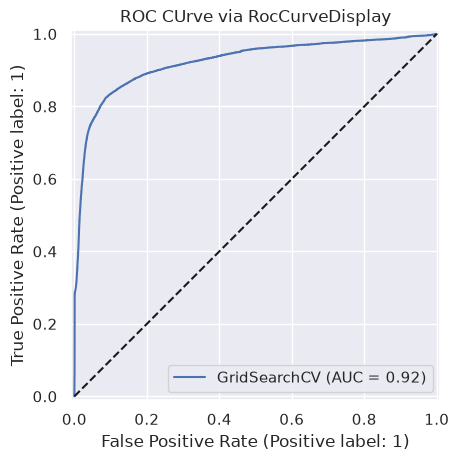

In [10]:
RocCurveDisplay.from_estimator(grid, X_test, y_test)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--')
plt.show()


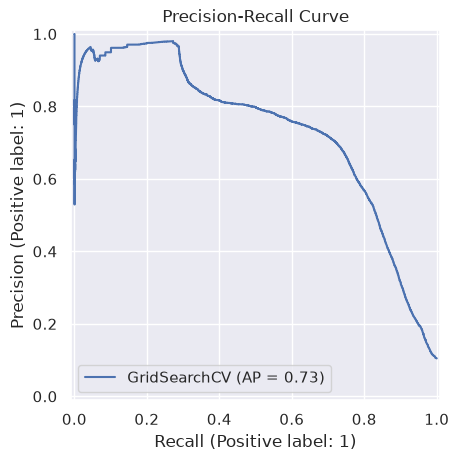

In [11]:

PrecisionRecallDisplay.from_estimator(grid, X_test, y_test)

plt.title('Precision-Recall Curve')
plt.show()

/home/ellie/research_project/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1395: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


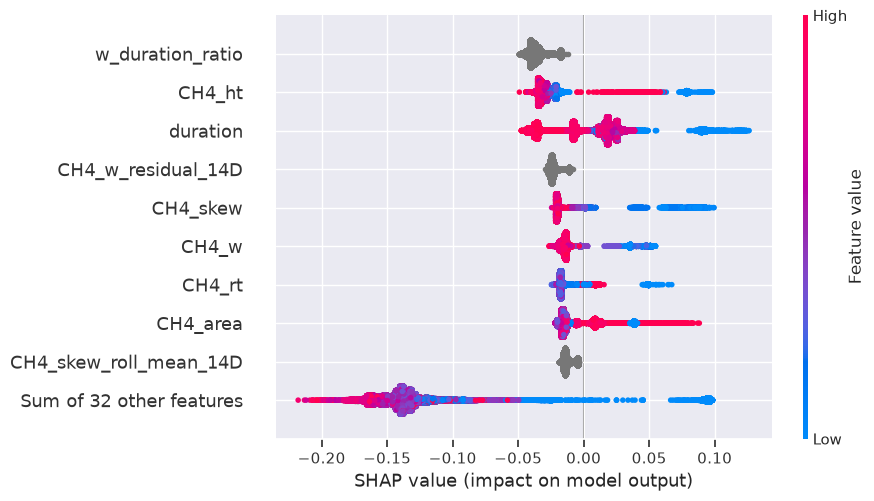

In [ ]:

#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)

#X_tsfe_demo = best_pipeline.named_steps['tsfe'].transform(X_test.head(2))
#feature_names = X_tsfe_demo.columns

#X_test_transformed_df = pd.DataFrame(X_test, columns =feature_names)
explainer = shap.TreeExplainer(final_rf_model)
shap_values = explainer(X_test_transformed_df)

shap.plots.beeswarm(shap_values[:, :, 1]) # label1 = 1

In [ ]:
# Learning curve
from sklearn.model_selection import LearningCurveDisplay
best_param = grid.best_estimator_

eval_pipeline = pipe_rnd.set_params(**best_param)

LearningCurveDisplay.from_estimator(
    eval_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    n_jobs=-1
)

plt.title("Learning Curve (Random Forest)")
plt.show()